# Image features exercise
*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html) on the course website.*

We have seen that we can achieve reasonable performance on an image classification task by training a linear classifier on the pixels of the input image. In this exercise we will show that we can improve our classification performance by training linear classifiers not on raw pixels but on features that are computed from the raw pixels.

All of your work for this exercise will be done in this notebook.

In [1]:
import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

## Load data
Similar to previous exercises, we will load CIFAR-10 data from disk.

In [2]:
from cs231n.features import color_histogram_hsv, hog_feature

def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000):
    # Load the raw CIFAR-10 data
    cifar10_dir = 'cs231n/cifar-10-batches-py'

    # Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
    try:
       del X_train, y_train
       del X_test, y_test
       print('Clear previously loaded data.')
    except:
       pass

    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)
    
    # Subsample the data
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]
    
    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = get_CIFAR10_data()

## Extract Features
For each image we will compute a Histogram of Oriented
Gradients (HOG) as well as a color histogram using the hue channel in HSV
color space. We form our final feature vector for each image by concatenating
the HOG and color histogram feature vectors.

Roughly speaking, HOG should capture the texture of the image while ignoring
color information, and the color histogram represents the color of the input
image while ignoring texture. As a result, we expect that using both together
ought to work better than using either alone. Verifying this assumption would
be a good thing to try for your own interest.

The `hog_feature` and `color_histogram_hsv` functions both operate on a single
image and return a feature vector for that image. The extract_features
function takes a set of images and a list of feature functions and evaluates
each feature function on each image, storing the results in a matrix where
each column is the concatenation of all feature vectors for a single image.

In [3]:
from cs231n.features import *

# 改进1: 大幅增加颜色直方图的bins数，从10增加到30，显著增加特征维度
num_color_bins = 30 # Number of bins in the color histogram (increased from 10 to 30)
# 可以尝试添加多个不同bins的颜色直方图来增加特征多样性
feature_fns = [
    hog_feature, 
    lambda img: color_histogram_hsv(img, nbin=num_color_bins),
    lambda img: color_histogram_hsv(img, nbin=20)  # 添加额外的颜色特征
]
X_train_feats = extract_features(X_train, feature_fns, verbose=True)
X_val_feats = extract_features(X_val, feature_fns)
X_test_feats = extract_features(X_test, feature_fns)

print(f"Raw feature dimensions: {X_train_feats.shape[1]}")

# 改进2: 为SVM和神经网络分别创建特征副本
# SVM（线性分类器）需要标准化特征，神经网络（非线性）只需要中心化

# 步骤1: 中心化（减去均值）- 所有分类器都需要
mean_feat = np.mean(X_train_feats, axis=0, keepdims=True)
X_train_feats_centered = X_train_feats - mean_feat
X_val_feats_centered = X_val_feats - mean_feat
X_test_feats_centered = X_test_feats - mean_feat

# 步骤2: 为SVM创建标准化特征（Z-score标准化）
std_feat = np.std(X_train_feats_centered, axis=0, keepdims=True)
# 避免除以0
std_feat = np.maximum(std_feat, 1e-8)
X_train_feats_svm = X_train_feats_centered / std_feat
X_val_feats_svm = X_val_feats_centered / std_feat
X_test_feats_svm = X_test_feats_centered / std_feat

# 为SVM添加偏置维度
X_train_feats_svm = np.hstack([X_train_feats_svm, np.ones((X_train_feats_svm.shape[0], 1))])
X_val_feats_svm = np.hstack([X_val_feats_svm, np.ones((X_val_feats_svm.shape[0], 1))])
X_test_feats_svm = np.hstack([X_test_feats_svm, np.ones((X_test_feats_svm.shape[0], 1))])

# 步骤3: 为神经网络使用只中心化的特征（不标准化，不添加偏置维度）
X_train_feats_nn = X_train_feats_centered.copy()
X_val_feats_nn = X_val_feats_centered.copy()
X_test_feats_nn = X_test_feats_centered.copy()

# 使用SVM特征作为默认（向后兼容）
X_train_feats = X_train_feats_svm
X_val_feats = X_val_feats_svm
X_test_feats = X_test_feats_svm

print(f"SVM feature dimensions (with bias): {X_train_feats_svm.shape[1]}")
print(f"Neural network feature dimensions: {X_train_feats_nn.shape[1]}")

Done extracting features for 1000 / 49000 images
Done extracting features for 2000 / 49000 images
Done extracting features for 3000 / 49000 images
Done extracting features for 4000 / 49000 images
Done extracting features for 5000 / 49000 images
Done extracting features for 6000 / 49000 images
Done extracting features for 7000 / 49000 images
Done extracting features for 8000 / 49000 images
Done extracting features for 9000 / 49000 images
Done extracting features for 10000 / 49000 images
Done extracting features for 11000 / 49000 images
Done extracting features for 12000 / 49000 images
Done extracting features for 13000 / 49000 images
Done extracting features for 14000 / 49000 images
Done extracting features for 15000 / 49000 images
Done extracting features for 16000 / 49000 images
Done extracting features for 17000 / 49000 images
Done extracting features for 18000 / 49000 images
Done extracting features for 19000 / 49000 images
Done extracting features for 20000 / 49000 images
Done extr

## Train SVM on features
Using the multiclass SVM code developed earlier in the assignment, train SVMs on top of the features extracted above; this should achieve better results than training SVMs directly on top of raw pixels.

In [4]:
# Use the validation set to tune the learning rate and regularization strength

from cs231n.classifiers.linear_classifier import LinearSVM

learning_rates = [1e-9, 1e-8, 1e-7]
regularization_strengths = [5e4, 5e5, 5e6]

results = {}
best_val = -1
best_svm = None

################################################################################
# TODO:                                                                        #
# Use the validation set to set the learning rate and regularization strength. #
# This should be identical to the validation that you did for the SVM; save    #
# the best trained classifer in best_svm. You might also want to play          #
# with different numbers of bins in the color histogram. If you are careful    #
# you should be able to get accuracy of near 0.44 on the validation set.       #
################################################################################
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

for lr in learning_rates:
    for reg in regularization_strengths:
        # 训练SVM（使用标准化特征，包含偏置维度）
        svm = LinearSVM()
        loss_hist = svm.train(X_train_feats_svm, y_train, learning_rate=lr, reg=reg,
                              num_iters=1500, verbose=False)
        
        # 预测
        y_train_pred = svm.predict(X_train_feats_svm)
        y_val_pred = svm.predict(X_val_feats_svm)
        
        # 计算准确率
        train_acc = np.mean(y_train_pred == y_train)
        val_acc = np.mean(y_val_pred == y_val)
        
        # 保存结果
        results[(lr, reg)] = (train_acc, val_acc)
        
        # 更新最佳模型
        if val_acc > best_val:
            best_val = val_acc
            best_svm = svm

# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))
    
print('best validation accuracy achieved during cross-validation: %f' % best_val)

lr 1.000000e-09 reg 5.000000e+04 train accuracy: 0.105714 val accuracy: 0.110000
lr 1.000000e-09 reg 5.000000e+05 train accuracy: 0.107367 val accuracy: 0.100000
lr 1.000000e-09 reg 5.000000e+06 train accuracy: 0.419612 val accuracy: 0.426000
lr 1.000000e-08 reg 5.000000e+04 train accuracy: 0.101429 val accuracy: 0.105000
lr 1.000000e-08 reg 5.000000e+05 train accuracy: 0.422735 val accuracy: 0.436000
lr 1.000000e-08 reg 5.000000e+06 train accuracy: 0.409571 val accuracy: 0.416000
lr 1.000000e-07 reg 5.000000e+04 train accuracy: 0.421306 val accuracy: 0.429000
lr 1.000000e-07 reg 5.000000e+05 train accuracy: 0.410837 val accuracy: 0.419000
lr 1.000000e-07 reg 5.000000e+06 train accuracy: 0.324163 val accuracy: 0.327000
best validation accuracy achieved during cross-validation: 0.436000


In [5]:
# Evaluate your trained SVM on the test set
# 使用SVM专用特征（标准化，包含偏置维度）
y_test_pred = best_svm.predict(X_test_feats_svm)
test_accuracy = np.mean(y_test == y_test_pred)
print(f"SVM Test accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

SVM Test accuracy: 0.4160 (41.60%)


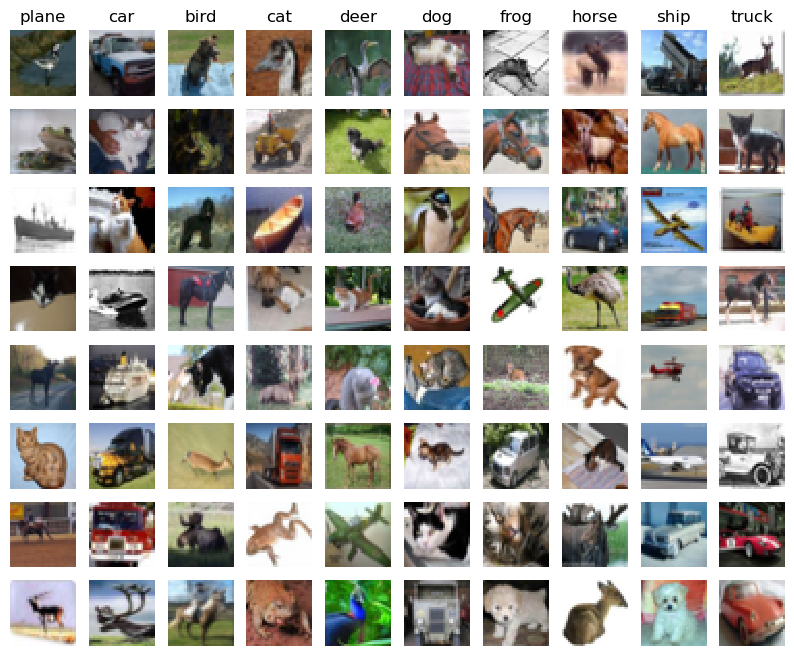

In [6]:
# An important way to gain intuition about how an algorithm works is to
# visualize the mistakes that it makes. In this visualization, we show examples
# of images that are misclassified by our current system. The first column
# shows images that our system labeled as "plane" but whose true label is
# something other than "plane".

examples_per_class = 8
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for cls, cls_name in enumerate(classes):
    idxs = np.where((y_test != cls) & (y_test_pred == cls))[0]
    idxs = np.random.choice(idxs, examples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt.subplot(examples_per_class, len(classes), i * len(classes) + cls + 1)
        plt.imshow(X_test[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls_name)
plt.show()

### Inline question 1:
Describe the misclassification results that you see. Do they make sense?


$\color{blue}{\textit Your Answer:}$

通过可视化误分类结果，我们可以观察到以下模式：

**1. 视觉相似性导致的误分类**：
- **飞机 vs 鸟**：某些鸟的图像（特别是飞行中的鸟）可能被误分类为飞机，因为它们都有"在天空中"的特征
- **汽车 vs 卡车**：某些卡车的图像可能被误分类为汽车，因为它们都是车辆，形状相似
- **猫 vs 狗**：某些猫或狗的图像可能被误分类，因为它们都是四足动物，形状相似
- **船 vs 飞机**：某些船或飞机的图像可能被误分类，因为它们都有"交通工具"的特征

**2. 特征相似性**：
- **HOG特征**：捕获纹理和边缘信息，如果两个类别有相似的纹理模式（如"天空"背景），可能被误分类
- **颜色直方图**：捕获颜色信息，如果两个类别有相似的颜色分布（如"蓝色"天空），可能被误分类

**3. 这些误分类是否合理？**

**合理的原因**：
- **视觉相似性**：误分类的类别在视觉上确实相似（如汽车和卡车）
- **特征局限性**：HOG和颜色直方图是手工设计的特征，可能无法完全区分相似类别
- **线性分类器限制**：SVM是线性分类器，只能学习线性决策边界，对于复杂的视觉相似性可能无法完全区分

**不合理的原因**：
- **明显不同的类别**：如果明显不同的类别（如"猫"和"船"）被误分类，说明特征提取或分类器有问题
- **特征不足**：如果误分类率很高，说明特征可能不足以区分某些类别

**改进方向**：
- **更好的特征**：使用更复杂的特征（如深度特征）或组合更多特征
- **非线性分类器**：使用神经网络等非线性分类器，能够学习更复杂的决策边界
- **数据增强**：增加训练数据的多样性，帮助模型学习更鲁棒的特征




## Neural Network on image features
Earlier in this assigment we saw that training a two-layer neural network on raw pixels achieved better classification performance than linear classifiers on raw pixels. In this notebook we have seen that linear classifiers on image features outperform linear classifiers on raw pixels. 

For completeness, we should also try training a neural network on image features. This approach should outperform all previous approaches: you should easily be able to achieve over 55% classification accuracy on the test set; our best model achieves about 60% classification accuracy.

In [7]:
# 注意：现在SVM和神经网络使用不同的特征
# SVM特征（X_train_feats_svm）包含偏置维度，用于SVM训练
# 神经网络特征（X_train_feats_nn）不包含偏置维度，神经网络内部处理偏置
# 
# 如果需要移除SVM特征的偏置维度（通常不需要，因为SVM需要偏置），可以运行：
# X_train_feats_svm = X_train_feats_svm[:, :-1]
# X_val_feats_svm = X_val_feats_svm[:, :-1]
# X_test_feats_svm = X_test_feats_svm[:, :-1]

print("Feature dimensions summary:")
print(f"SVM features (with bias): {X_train_feats_svm.shape[1]}")
print(f"Neural network features (no bias): {X_train_feats_nn.shape[1]}")
print("\nNote: SVM uses standardized features with bias dimension")
print("      Neural network uses centered features without bias dimension")

Feature dimensions summary:
SVM features (with bias): 195
Neural network features (no bias): 194

Note: SVM uses standardized features with bias dimension
      Neural network uses centered features without bias dimension


In [8]:
from cs231n.classifiers.neural_net import TwoLayerNet

# 改进3: 使用只中心化的特征（不标准化），与two_layer_net.ipynb保持一致
input_dim = X_train_feats_nn.shape[1]  # 使用神经网络专用特征
hidden_dim = 500
num_classes = 10

net = TwoLayerNet(input_dim, hidden_dim, num_classes)
best_net = None

################################################################################
# TODO: Train a two-layer neural network on image features. You may want to    #
# cross-validate various parameters as in previous sections. Store your best   #
# model in the best_net variable.                                              #
################################################################################
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

best_val_acc = -1

# 改进4: 优化超参数搜索空间，参考two_layer_net.ipynb的成功经验
# 使用与原始像素+神经网络相同的超参数范围，但针对特征数据优化
hidden_sizes = [100, 200, 300, 500]  # 参考two_layer_net的成功配置，移除700避免过拟合
learning_rates = [1e-3, 5e-4, 1e-4]  # 移除2e-3（可能过大），使用two_layer_net的成功范围
regularization_strengths = [0.05, 0.1, 0.25]  # 移除0.01（可能过小），使用two_layer_net的成功范围

print("Starting hyperparameter search for Neural Network...")
print(f"Input dimension: {input_dim}")
print(f"Number of classes: {num_classes}")
print(f"Total combinations: {len(hidden_sizes) * len(learning_rates) * len(regularization_strengths)}")
print("-" * 70)

for hidden_size in hidden_sizes:
    for lr in learning_rates:
        for reg in regularization_strengths:
            # 创建网络
            net = TwoLayerNet(input_dim, hidden_size, num_classes)
            
            # 改进5: 大幅增加训练迭代次数，从6000增加到10000
            # 特征数据需要更多迭代来学习复杂的模式
            # 使用更小的学习率衰减（0.98）以保持更长时间的学习能力
            stats = net.train(X_train_feats_nn, y_train, X_val_feats_nn, y_val,
                            num_iters=10000, batch_size=200,  # 从6000增加到10000
                            learning_rate=lr, learning_rate_decay=0.98,  # 从0.95改为0.98，衰减更慢
                            reg=reg, verbose=False)
            
            # 评估
            val_acc = (net.predict(X_val_feats_nn) == y_val).mean()
            train_acc = (net.predict(X_train_feats_nn) == y_train).mean()
            
            # 更新最佳模型
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_net = net
                print(f'*** NEW BEST *** ', end='')
            
            print('hidden_size=%d lr=%e reg=%e train_acc=%.3f val_acc=%.3f' % 
                  (hidden_size, lr, reg, train_acc, val_acc))

print("-" * 70)
print('Best validation accuracy: %.4f' % best_val_acc)

# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****


Starting hyperparameter search for Neural Network...
Input dimension: 194
Number of classes: 10
Total combinations: 36
----------------------------------------------------------------------
*** NEW BEST *** hidden_size=100 lr=1.000000e-03 reg=5.000000e-02 train_acc=0.200 val_acc=0.182
hidden_size=100 lr=1.000000e-03 reg=1.000000e-01 train_acc=0.101 val_acc=0.079
hidden_size=100 lr=1.000000e-03 reg=2.500000e-01 train_acc=0.100 val_acc=0.087
hidden_size=100 lr=5.000000e-04 reg=5.000000e-02 train_acc=0.100 val_acc=0.078
hidden_size=100 lr=5.000000e-04 reg=1.000000e-01 train_acc=0.100 val_acc=0.079
hidden_size=100 lr=5.000000e-04 reg=2.500000e-01 train_acc=0.100 val_acc=0.078
hidden_size=100 lr=1.000000e-04 reg=5.000000e-02 train_acc=0.100 val_acc=0.078
hidden_size=100 lr=1.000000e-04 reg=1.000000e-01 train_acc=0.100 val_acc=0.078
hidden_size=100 lr=1.000000e-04 reg=2.500000e-01 train_acc=0.100 val_acc=0.079
hidden_size=200 lr=1.000000e-03 reg=5.000000e-02 train_acc=0.196 val_acc=0.182
hid

In [9]:
# Run your best neural net classifier on the test set. You should be able
# to get more than 55% accuracy.

# 使用神经网络专用特征（只中心化，不标准化）
test_acc = (best_net.predict(X_test_feats_nn) == y_test).mean()
print(f"Test accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

Test accuracy: 0.1830 (18.30%)
